In [1]:
# import wandb
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# api = wandb.Api()

# # Pull all finished runs from both sweeps
# # runs = api.runs("your-entity/master-thesis-mel-nv")
# link = "choekyel-nyungmartsang-university-of-bern/master-thesis-mel-nv"
# runs = api.runs(link)

# records = []
# for run in runs:
#     # Only include completed lambda sweep runs
#     if run.state != "finished":
#         continue
#     cfg = run.config
#     if cfg.get("pooling") not in ("mean", "cls"):
#         continue

#     s = run.summary._json_dict
#     records.append({
#         "pooling":                   cfg.get("pooling"),
#         "ha_lambda":                 cfg.get("ha_lambda", 0.0),
#         "val_auc_roc":               s.get("val/auc_roc"),
#         "val_ha_dice":               s.get("val/ha_dice"),
#         "val_balanced_acc":          s.get("val/balanced_accuracy"),
#         "val_inside_minus":          s.get("val/inside_minus_area_baseline"),
#         "test_auc_roc":              s.get("test/auc_roc"),
#         "test_ha_dice":              s.get("test/ha_dice"),
#         "test_inside_minus":         s.get("test/inside_minus_area_baseline"),
#     })

# df = pd.DataFrame(records).sort_values(["pooling", "ha_lambda"])
# print(df.to_string(index=False))

# # ── Figure 1: Pareto frontier AUC vs HA Dice ──────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# colors = {"mean": "steelblue", "cls": "darkorange"}
# markers = {"mean": "o", "cls": "s"}

# for pooling, grp in df.groupby("pooling"):
#     grp = grp.sort_values("val_ha_dice")
#     axes[0].plot(
#         grp["val_ha_dice"], grp["val_auc_roc"],
#         marker=markers[pooling], color=colors[pooling],
#         linewidth=2, label=f"{pooling} pooling"
#     )
#     for _, row in grp.iterrows():
#         axes[0].annotate(
#             f"λ={row['ha_lambda']}",
#             (row["val_ha_dice"], row["val_auc_roc"]),
#             textcoords="offset points", xytext=(4, 3), fontsize=7
#         )

# axes[0].set_xlabel("val / HA Dice")
# axes[0].set_ylabel("val / AUC-ROC")
# axes[0].set_title("Pareto Frontier: AUC vs HA Dice")
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# # ── Figure 2: inside_minus_area_baseline vs lambda ────────────────────────
# for pooling, grp in df.groupby("pooling"):
#     grp = grp[grp["val_inside_minus"].notna()].sort_values("ha_lambda")
#     axes[1].plot(
#         grp["ha_lambda"], grp["val_inside_minus"],
#         marker=markers[pooling], color=colors[pooling],
#         linewidth=2, label=f"{pooling} pooling"
#     )

# axes[1].axhline(0, color="red", linestyle="--", linewidth=1, label="random baseline")
# axes[1].set_xlabel("HA Lambda")
# axes[1].set_ylabel("val / inside_minus_area_baseline")
# axes[1].set_title("CAM Spatial Alignment vs Lambda")
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# # ── Figure 3: balanced accuracy vs lambda ─────────────────────────────────
# for pooling, grp in df.groupby("pooling"):
#     grp = grp.sort_values("ha_lambda")
#     axes[2].plot(
#         grp["ha_lambda"], grp["val_balanced_acc"],
#         marker=markers[pooling], color=colors[pooling],
#         linewidth=2, label=f"{pooling} pooling"
#     )

# axes[2].set_xlabel("HA Lambda")
# axes[2].set_ylabel("val / Balanced Accuracy")
# axes[2].set_title("Classification Performance vs Lambda")
# axes[2].legend()
# axes[2].grid(True, alpha=0.3)

# plt.suptitle("Mean vs CLS Pooling: HA Lambda Sweep", fontsize=13, fontweight="bold")
# plt.tight_layout()
# # plt.savefig("ha_lambda_sweep_comparison.png", dpi=150, bbox_inches="tight")
# plt.show()
# # print("Saved: ha_lambda_sweep_comparison.png")

In [2]:
# import wandb

# api = wandb.Api()

# print("Viewer:")
# print(api.viewer)

# print("\nDefault entity:")
# print(getattr(api, "default_entity", None))

# # Try likely entities
# candidate_entities = [
#     "choekyel-nyungmartsang-university-of-bern",
#     "choekyel-nyungmartsang",
#     "choekyel",
# ]

# for entity in candidate_entities:
#     print("\n" + "=" * 80)
#     print(f"Trying entity: {entity}")
#     try:
#         projects = list(api.projects(entity=entity))
#         print(f"Found {len(projects)} projects")
#         for p in projects:
#             print("  ", p.name)
#     except Exception as e:
#         print("ERROR:", repr(e))

In [3]:
# import wandb

# api = wandb.Api()
# entity = api.default_entity

# print("default entity:", entity)

# projects = list(api.projects(entity=entity))
# for p in projects:
#     print(p.name)

In [4]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import wandb

warnings.filterwarnings("ignore")

%matplotlib inline

In [5]:
WANDB_LINK = "choekyel-nyungmartsang-university-of-bern/master-thesis-mel-nv"

SAVE_FIGURES = False
FIGURE_DPI = 150
OUT_PREFIX = "ha_sweep"
OUT_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)

RUN_NAME_PREFIX = "sweep_ha__"

COLORS = {
    "mean": "steelblue",
    "cls": "darkorange",
}

MARKERS = {
    "mean": "o",
    "cls": "s",
}

POOLING_LABELS = {
    "mean": "Mean pooling",
    "cls": "CLS pooling",
}

TABLE_METRICS = [
    ("val_auc_roc", "Val AUC-ROC"),
    ("val_balanced_acc", "Val Bal.Acc"),
    ("val_ha_dice", "Val HA-Dice"),
    ("val_inside_minus", "Val Inside-Δ"),
    ("test_auc_roc", "Test AUC-ROC"),
    ("test_ha_dice", "Test HA-Dice"),
    ("test_inside_minus", "Test Inside-Δ"),
]

In [6]:
api = wandb.Api()

print("Viewer:", api.viewer)
print("Default entity:", api.default_entity)

entity, project = WANDB_LINK.split("/")
print("Target entity:", entity)
print("Target project:", project)

projects = list(api.projects(entity=entity))
print("\nProjects under target entity:")
for p in projects:
    print(" ", p.name)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/choekyelnyungmartsang/.netrc.


Viewer: <User choekyel.nyungmartsang@students.unibe.ch>
Default entity: choekyel-nyungmartsang-university-of-bern
Target entity: choekyel-nyungmartsang-university-of-bern
Target project: master-thesis-mel-nv

Projects under target entity:
  master-thesis-mel-nv
  master-thesis-panderm-ha


In [7]:
runs_preview = list(api.runs(WANDB_LINK))

print(f"Found {len(runs_preview)} total runs in {WANDB_LINK}")

for run in runs_preview[:20]:
    print(f"{run.state:>10} | {run.name}")

Found 20 total runs in choekyel-nyungmartsang-university-of-bern/master-thesis-mel-nv
  finished | sweep_ha__mean__l0p0__ep10__lr1e5
  finished | sweep_ha__mean__l0p1__ep10__lr1e5
  finished | sweep_ha__mean__l0p5__ep10__lr1e5
  finished | sweep_ha__mean__l0p25__ep10__lr1e5
  finished | sweep_ha__mean__l3p0__ep10__lr1e5
  finished | sweep_ha__mean__l1p0__ep10__lr1e5
  finished | sweep_ha__mean__l7p0__ep10__lr1e5
  finished | sweep_ha__mean__l5p0__ep10__lr1e5
  finished | sweep_ha__mean__l17p0__ep10__lr1e5
  finished | sweep_ha__mean__l11p0__ep10__lr1e5
  finished | sweep_ha__cls__l0p1__ep10__lr1e5
  finished | sweep_ha__cls__l0p0__ep10__lr1e5
  finished | sweep_ha__cls__l0p25__ep10__lr1e5
  finished | sweep_ha__cls__l0p5__ep10__lr1e5
  finished | sweep_ha__cls__l3p0__ep10__lr1e5
  finished | sweep_ha__cls__l1p0__ep10__lr1e5
  finished | sweep_ha__cls__l5p0__ep10__lr1e5
  finished | sweep_ha__cls__l7p0__ep10__lr1e5
  finished | sweep_ha__cls__l17p0__ep10__lr1e5
  finished | sweep_ha__cl

In [8]:
def parse_lambda_from_name(name: str):
    match = re.search(r"__l([0-9]+p[0-9]+)__", name)
    if match is None:
        return None
    return float(match.group(1).replace("p", "."))


def parse_pooling_from_name(name: str):
    match = re.search(r"__(mean|cls)__", name)
    if match is None:
        return None
    return match.group(1)


def pull_runs(link: str, prefix: str) -> pd.DataFrame:
    api = wandb.Api()
    runs = api.runs(link)

    records = []
    skipped = []

    for run in runs:
        if run.state != "finished":
            skipped.append((run.name, f"state={run.state}"))
            continue

        if prefix and not run.name.startswith(prefix):
            skipped.append((run.name, "prefix mismatch"))
            continue

        name = run.name
        pooling = parse_pooling_from_name(name)
        ha_lambda = parse_lambda_from_name(name)

        if pooling is None:
            pooling = run.config.get("pooling")

        if ha_lambda is None:
            ha_lambda = run.config.get("ha_lambda")

        if pooling not in ("mean", "cls"):
            skipped.append((name, "pooling missing"))
            continue

        if ha_lambda is None:
            skipped.append((name, "lambda missing"))
            continue

        try:
            ha_lambda = float(ha_lambda)
        except Exception:
            skipped.append((name, "lambda not numeric"))
            continue

        s = run.summary._json_dict

        records.append({
            "run_name": name,
            "run_id": run.id,
            "run_url": run.url,
            "pooling": pooling,
            "ha_lambda": ha_lambda,

            "val_auc_roc": s.get("val/auc_roc"),
            "val_balanced_acc": s.get("val/balanced_accuracy"),
            "val_recall": s.get("val/recall_macro"),
            "val_ha_dice": s.get("val/ha_dice"),
            "val_inside_minus": s.get("val/inside_minus_area_baseline"),
            "val_inside_frac": s.get("val/inside_cam_fraction"),
            "val_outside_dens": s.get("val/outside_density"),
            "val_cam_nz_frac": s.get("val/cam_nonzero_fraction"),
            "val_loss": s.get("val/loss"),

            "test_auc_roc": s.get("test/auc_roc"),
            "test_balanced_acc": s.get("test/balanced_accuracy"),
            "test_ha_dice": s.get("test/ha_dice"),
            "test_inside_minus": s.get("test/inside_minus_area_baseline"),

            "train_ha_loss": s.get("train/ha_loss"),
            "train_cls_loss": s.get("train/cls_loss"),
        })

    if skipped:
        print(f"Skipped {len(skipped)} runs.")
        for name, reason in skipped[:15]:
            print(f"  {reason:>18} | {name}")
        if len(skipped) > 15:
            print(f"  ... and {len(skipped) - 15} more")

    df = pd.DataFrame(records)

    if df.empty:
        return df

    df = (
        df
        .sort_values(["pooling", "ha_lambda"])
        .reset_index(drop=True)
    )

    return df

In [9]:
df = pull_runs(WANDB_LINK, RUN_NAME_PREFIX)

print(f"Loaded {len(df)} matching finished runs.")

if df.empty:
    print("No matching runs found.")
    print("Try setting RUN_NAME_PREFIX = '' if your runs do not start with sweep_ha__.")
else:
    display(df[["run_name", "pooling", "ha_lambda", "val_auc_roc", "val_ha_dice", "val_inside_minus"]])

Loaded 20 matching finished runs.


,run_name,pooling,ha_lambda,val_auc_roc,val_ha_dice,val_inside_minus
0,sweep_ha__cls__l0p0__ep10__lr1e5,cls,0.00,0.976465,NaN,NaN
1,sweep_ha__cls__l0p1__ep10__lr1e5,cls,0.10,0.973939,0.541558,0.491013
2,sweep_ha__cls__l0p25__ep10__lr1e5,cls,0.25,0.973838,0.661654,0.509529
3,sweep_ha__cls__l0p5__ep10__lr1e5,cls,0.50,0.972727,0.720894,0.530185
4,sweep_ha__cls__l1p0__ep10__lr1e5,cls,1.00,0.970404,0.762197,0.546620
5,sweep_ha__cls__l3p0__ep10__lr1e5,cls,3.00,0.964848,0.796973,0.561609
6,sweep_ha__cls__l5p0__ep10__lr1e5,cls,5.00,0.957374,0.803631,0.564363
7,sweep_ha__cls__l7p0__ep10__lr1e5,cls,7.00,0.954040,0.806291,0.566126
8,sweep_ha__cls__l11p0__ep10__lr1e5,cls,11.00,0.948889,0.809846,0.568544
9,sweep_ha__cls__l17p0__ep10__lr1e5,cls,17.00,0.941010,0.811817,0.569184


In [10]:
if not df.empty:
    csv_path = f"{OUT_PREFIX}_results_table.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path}")

Saved: ha_sweep_results_table.csv


In [11]:
def print_summary_table(df: pd.DataFrame) -> None:
    print("\n" + "=" * 90)
    print("SUMMARY TABLE: HA Lambda Sweep")
    print("=" * 90)

    col_keys = [m[0] for m in TABLE_METRICS]
    col_labels = [m[1] for m in TABLE_METRICS]

    header = f"{'Pooling':>6}  {'Lambda':>7}  " + "  ".join(f"{c:>12}" for c in col_labels)
    print(header)
    print("-" * len(header))

    for pooling, grp in df.groupby("pooling", sort=True):
        for _, row in grp.iterrows():
            vals = []
            for k in col_keys:
                v = row.get(k)
                vals.append(f"{v:>12.4f}" if pd.notna(v) else f"{'n/a':>12}")
            lam = f"{row['ha_lambda']:.2f}"
            print(f"{pooling:>6}  {lam:>7}  " + "  ".join(vals))
        print()

    print("=" * 90)
    print("BEST RUNS PER POOLING MODE BY VAL AUC-ROC")
    print("-" * 90)

    for pooling, grp in df.groupby("pooling"):
        sub = grp[grp["val_auc_roc"].notna()]
        if sub.empty:
            continue

        best = sub.loc[sub["val_auc_roc"].idxmax()]
        print(
            f"  {pooling:>4}: "
            f"λ={best['ha_lambda']:.2f}  "
            f"val_auc={best['val_auc_roc']:.4f}  "
            f"val_dice={best['val_ha_dice']:.4f}  "
            f"val_inside_minus={best['val_inside_minus']:.4f}"
        )

    print("=" * 90)
    print("BEST RUNS PER POOLING MODE BY VAL HA-DICE")
    print("-" * 90)

    for pooling, grp in df.groupby("pooling"):
        sub = grp[grp["val_ha_dice"].notna()]
        if sub.empty:
            continue

        best = sub.loc[sub["val_ha_dice"].idxmax()]
        print(
            f"  {pooling:>4}: "
            f"λ={best['ha_lambda']:.2f}  "
            f"val_auc={best['val_auc_roc']:.4f}  "
            f"val_dice={best['val_ha_dice']:.4f}  "
            f"val_inside_minus={best['val_inside_minus']:.4f}"
        )

    print("=" * 90 + "\n")


if not df.empty:
    print_summary_table(df)


SUMMARY TABLE: HA Lambda Sweep
Pooling   Lambda   Val AUC-ROC   Val Bal.Acc   Val HA-Dice  Val Inside-Δ  Test AUC-ROC  Test HA-Dice  Test Inside-Δ
-------------------------------------------------------------------------------------------------------------------
   cls     0.00        0.9765        0.9162           n/a           n/a        0.9757           n/a           n/a
   cls     0.10        0.9739        0.9023        0.5416        0.4910        0.9750        0.5337        0.4806
   cls     0.25        0.9738        0.8774        0.6617        0.5095        0.9691        0.6261        0.4845
   cls     0.50        0.9727        0.8740        0.7209        0.5302        0.9682        0.6866        0.5045
   cls     1.00        0.9704        0.8729        0.7622        0.5466        0.9659        0.7283        0.5186
   cls     3.00        0.9648        0.8879        0.7970        0.5616        0.9642        0.7886        0.5453
   cls     5.00        0.9574        0.9073        0

In [12]:
def save_or_show(fig: plt.Figure, name: str) -> None:
    if SAVE_FIGURES:
        path = OUT_DIR / f"{OUT_PREFIX}_{name}.png"
        fig.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Saved: {path}")
    plt.show()

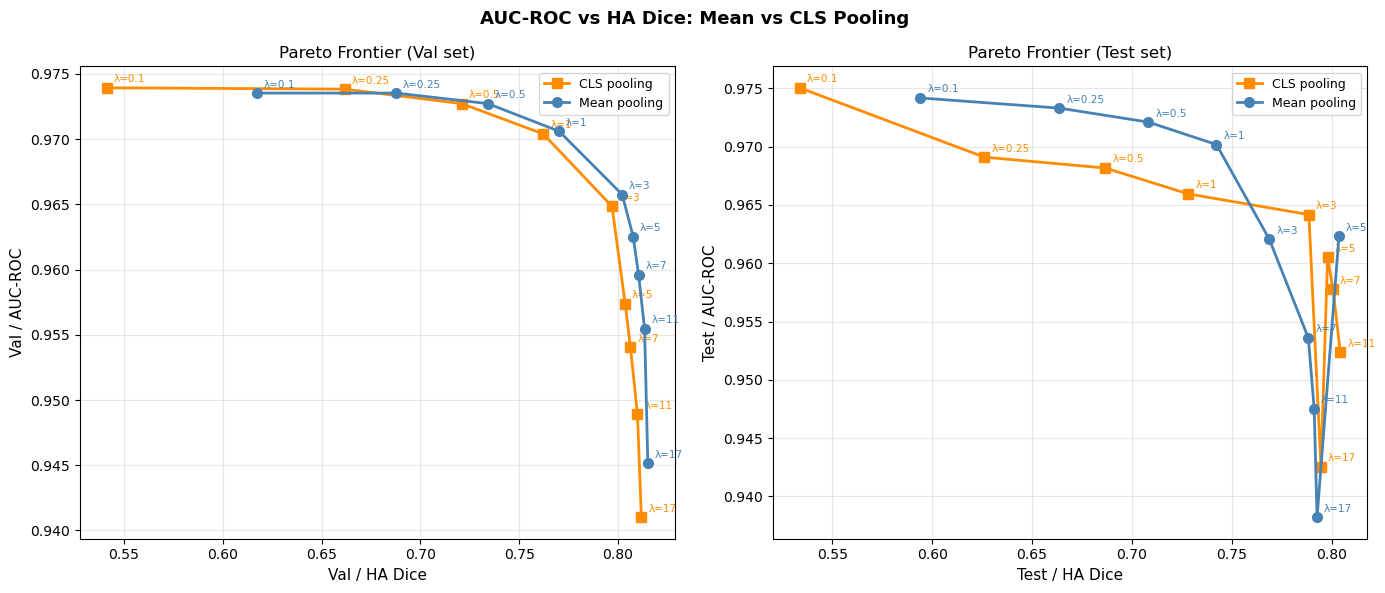

In [13]:
def plot_pareto(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, split in zip(axes, ["val", "test"]):
        x_col = f"{split}_ha_dice"
        y_col = f"{split}_auc_roc"

        for pooling, grp in df.groupby("pooling"):
            sub = grp[[x_col, y_col, "ha_lambda"]].dropna().sort_values(x_col)

            if sub.empty:
                continue

            ax.plot(
                sub[x_col],
                sub[y_col],
                marker=MARKERS[pooling],
                color=COLORS[pooling],
                linewidth=2,
                markersize=7,
                label=POOLING_LABELS[pooling],
                zorder=3,
            )

            for _, row in sub.iterrows():
                ax.annotate(
                    f"λ={row['ha_lambda']:.2g}",
                    (row[x_col], row[y_col]),
                    textcoords="offset points",
                    xytext=(5, 4),
                    fontsize=7.5,
                    color=COLORS[pooling],
                )

        ax.set_xlabel(f"{split.capitalize()} / HA Dice", fontsize=11)
        ax.set_ylabel(f"{split.capitalize()} / AUC-ROC", fontsize=11)
        ax.set_title(f"Pareto Frontier ({split.capitalize()} set)", fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    plt.suptitle("AUC-ROC vs HA Dice: Mean vs CLS Pooling", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "pareto")


if not df.empty:
    plot_pareto(df)

- `>` better CAM alignment
- `^` better classification
- after lambda = 3, the classification is getting worse
- mean pooling generalises better at high lambda

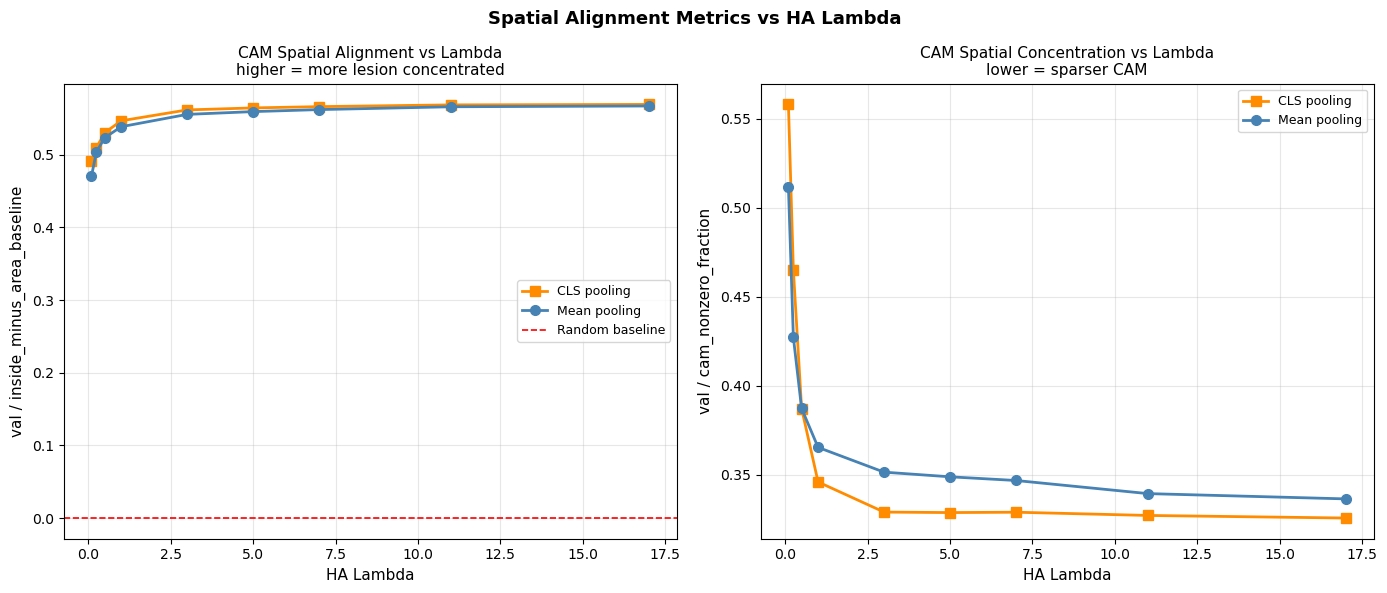

In [14]:
def plot_alignment_vs_lambda(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for pooling, grp in df.groupby("pooling"):
        sub = grp[grp["val_inside_minus"].notna()].sort_values("ha_lambda")

        if not sub.empty:
            axes[0].plot(
                sub["ha_lambda"],
                sub["val_inside_minus"],
                marker=MARKERS[pooling],
                color=COLORS[pooling],
                linewidth=2,
                markersize=7,
                label=POOLING_LABELS[pooling],
            )

        sub2 = grp[grp["val_cam_nz_frac"].notna()].sort_values("ha_lambda")

        if not sub2.empty:
            axes[1].plot(
                sub2["ha_lambda"],
                sub2["val_cam_nz_frac"],
                marker=MARKERS[pooling],
                color=COLORS[pooling],
                linewidth=2,
                markersize=7,
                label=POOLING_LABELS[pooling],
            )

    axes[0].axhline(0, color="red", linestyle="--", linewidth=1.2, label="Random baseline")
    axes[0].set_xlabel("HA Lambda", fontsize=11)
    axes[0].set_ylabel("val / inside_minus_area_baseline", fontsize=11)
    axes[0].set_title("CAM Spatial Alignment vs Lambda\nhigher = more lesion concentrated", fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    axes[1].set_xlabel("HA Lambda", fontsize=11)
    axes[1].set_ylabel("val / cam_nonzero_fraction", fontsize=11)
    axes[1].set_title("CAM Spatial Concentration vs Lambda\nlower = sparser CAM", fontsize=11)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle("Spatial Alignment Metrics vs HA Lambda", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "alignment_vs_lambda")


if not df.empty:
    plot_alignment_vs_lambda(df)

- Left: is the CAM pointing at the lesion above chance?
- Right: how spatially focused is the CAM? lower = CAM activates fewer pixels = more precise spotlight on the lesion.
- curve rises steeply until lambda = 3, then flattens out. Both saturate at 0.57
- CLS produces a more concentrated and sharper CAM (right plot)

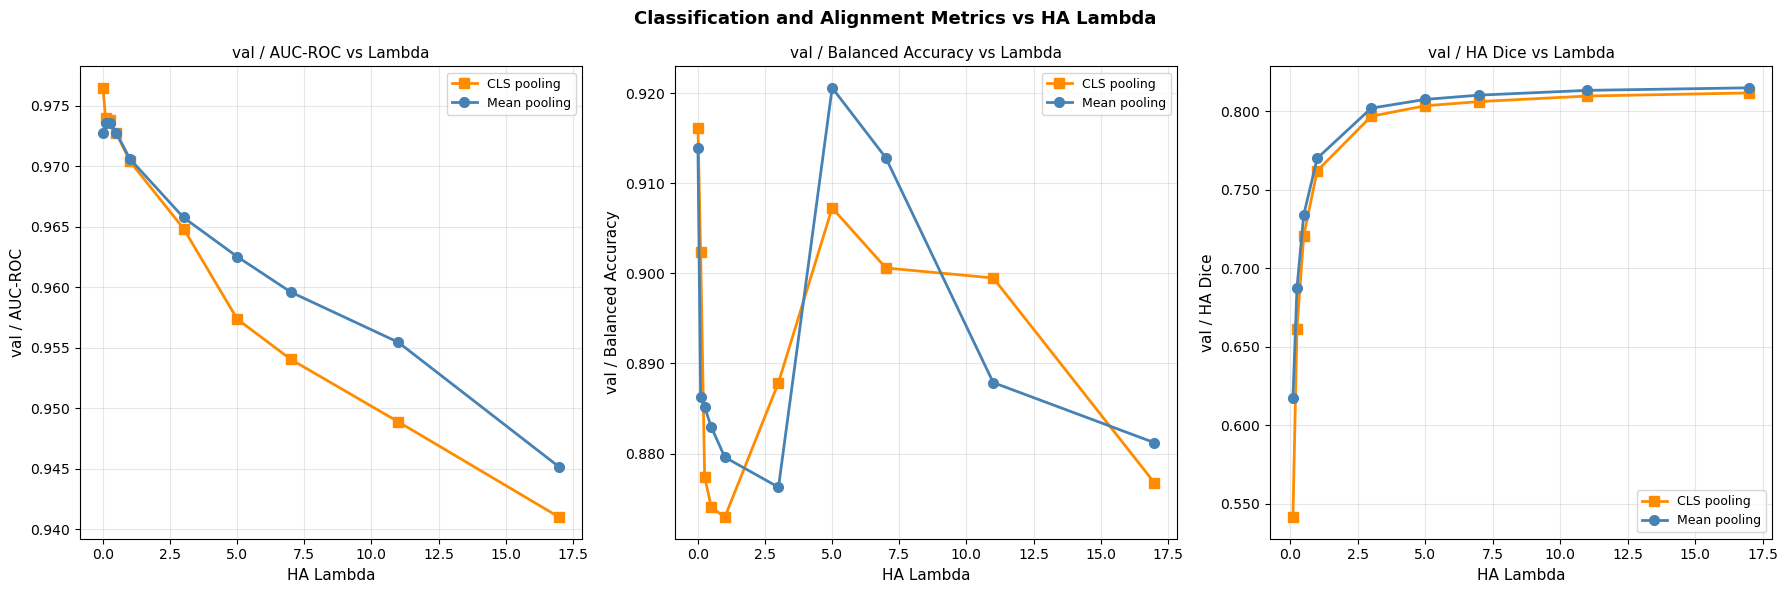

In [15]:
def plot_classification_vs_lambda(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    metrics = [
        ("val_auc_roc", "val / AUC-ROC", axes[0]),
        ("val_balanced_acc", "val / Balanced Accuracy", axes[1]),
        ("val_ha_dice", "val / HA Dice", axes[2]),
    ]

    for col, ylabel, ax in metrics:
        for pooling, grp in df.groupby("pooling"):
            sub = grp[grp[col].notna()].sort_values("ha_lambda")

            if sub.empty:
                continue

            ax.plot(
                sub["ha_lambda"],
                sub[col],
                marker=MARKERS[pooling],
                color=COLORS[pooling],
                linewidth=2,
                markersize=7,
                label=POOLING_LABELS[pooling],
            )

        ax.set_xlabel("HA Lambda", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(ylabel + " vs Lambda", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

    plt.suptitle("Classification and Alignment Metrics vs HA Lambda", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "metrics_vs_lambda")


if not df.empty:
    plot_classification_vs_lambda(df)

- (left plot) both decline monotonically
- (center plot) both peak at lambda = 5

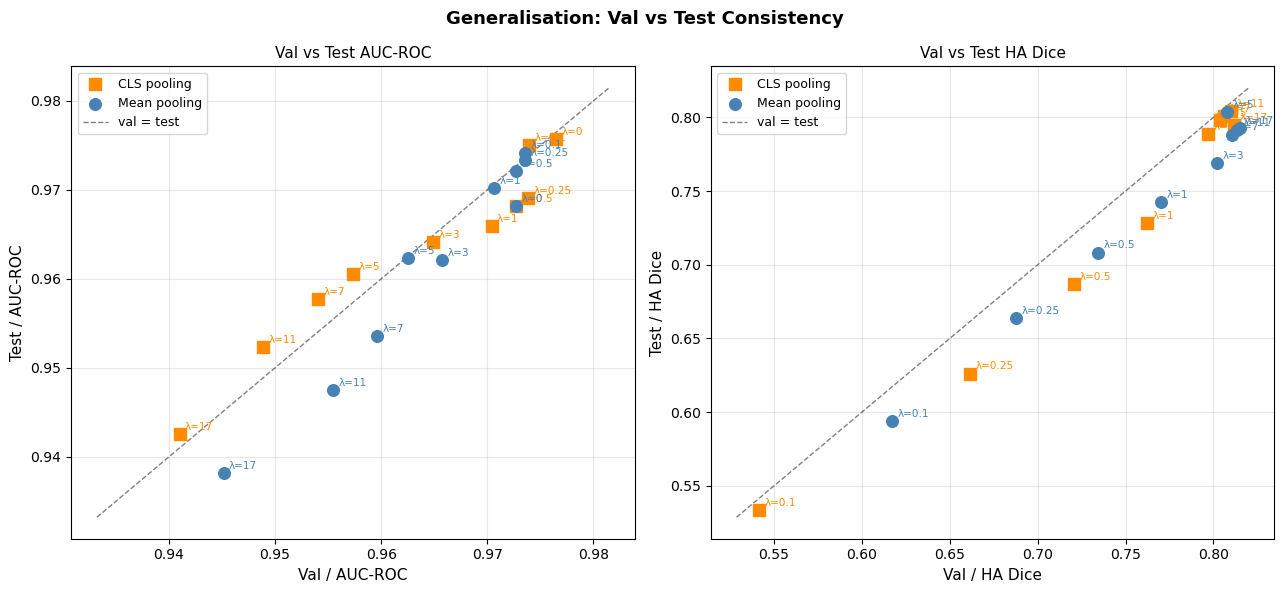

In [16]:
def plot_val_vs_test_consistency(df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    plot_specs = [
        (axes[0], "auc_roc", "AUC-ROC"),
        (axes[1], "ha_dice", "HA Dice"),
    ]

    for ax, metric, label in plot_specs:
        val_col = f"val_{metric}"
        test_col = f"test_{metric}"

        for pooling, grp in df.groupby("pooling"):
            sub = grp[[val_col, test_col, "ha_lambda"]].dropna()

            if sub.empty:
                continue

            ax.scatter(
                sub[val_col],
                sub[test_col],
                marker=MARKERS[pooling],
                color=COLORS[pooling],
                s=70,
                zorder=3,
                label=POOLING_LABELS[pooling],
            )

            for _, row in sub.iterrows():
                ax.annotate(
                    f"λ={row['ha_lambda']:.2g}",
                    (row[val_col], row[test_col]),
                    textcoords="offset points",
                    xytext=(4, 3),
                    fontsize=7.5,
                    color=COLORS[pooling],
                )

        all_vals = pd.concat([df[val_col], df[test_col]]).dropna()

        if not all_vals.empty:
            lo = all_vals.min() - 0.005
            hi = all_vals.max() + 0.005
            ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, alpha=0.5, label="val = test")

        ax.set_xlabel(f"Val / {label}", fontsize=11)
        ax.set_ylabel(f"Test / {label}", fontsize=11)
        ax.set_title(f"Val vs Test {label}", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Generalisation: Val vs Test Consistency", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "val_vs_test")


if not df.empty:
    plot_val_vs_test_consistency(df)

- (left plot) points above diagonal = test better than val (good sign). low lambdas are near diagonal (good generalisation), high lambda drift away, CLS is better at high lambda.
- (right plot) both modes generalise alignment imperfectly with the gap growing at extremes.

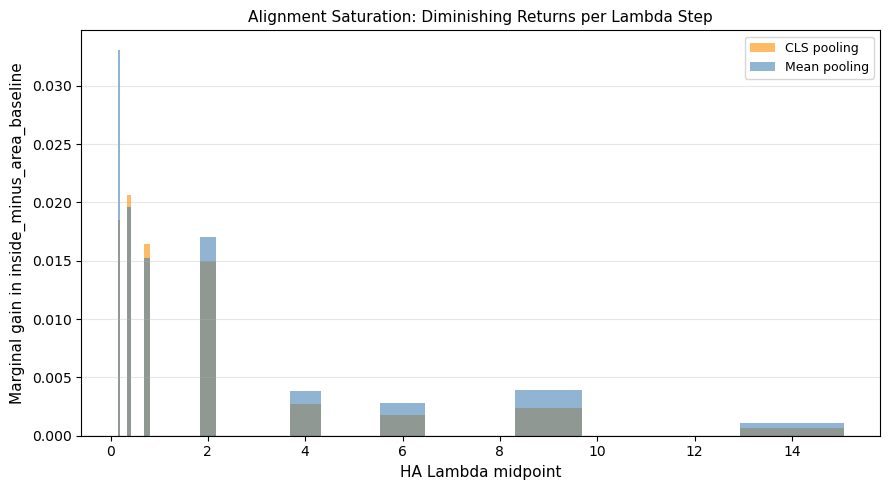

In [17]:
def plot_alignment_saturation(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))

    for pooling, grp in df.groupby("pooling"):
        sub = (
            grp[grp["val_inside_minus"].notna()]
            .sort_values("ha_lambda")
            .reset_index(drop=True)
        )

        if len(sub) < 2:
            continue

        marginal_gain = sub["val_inside_minus"].diff()
        lambda_midpoints = (
            sub["ha_lambda"].values[:-1] + sub["ha_lambda"].values[1:]
        ) / 2.0

        widths = np.maximum(lambda_midpoints * 0.15 + 0.03, 0.04)

        ax.bar(
            lambda_midpoints,
            marginal_gain.iloc[1:],
            width=widths,
            color=COLORS[pooling],
            alpha=0.6,
            label=POOLING_LABELS[pooling],
        )

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("HA Lambda midpoint", fontsize=11)
    ax.set_ylabel("Marginal gain in inside_minus_area_baseline", fontsize=11)
    ax.set_title("Alignment Saturation: Diminishing Returns per Lambda Step", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    save_or_show(fig, "alignment_saturation")


if not df.empty:
    plot_alignment_saturation(df)

- What it shows: Each bar is the extra alignment gain from increasing lambda one step. Tall bar = lambda is still buying you something. Tiny bar = you are wasting compute.
- The bars are tall up to λ≈2, then collapse to near zero. The entire alignment budget is spent by λ=3. Everything above λ=3 costs AUC for zero additional alignment benefit.

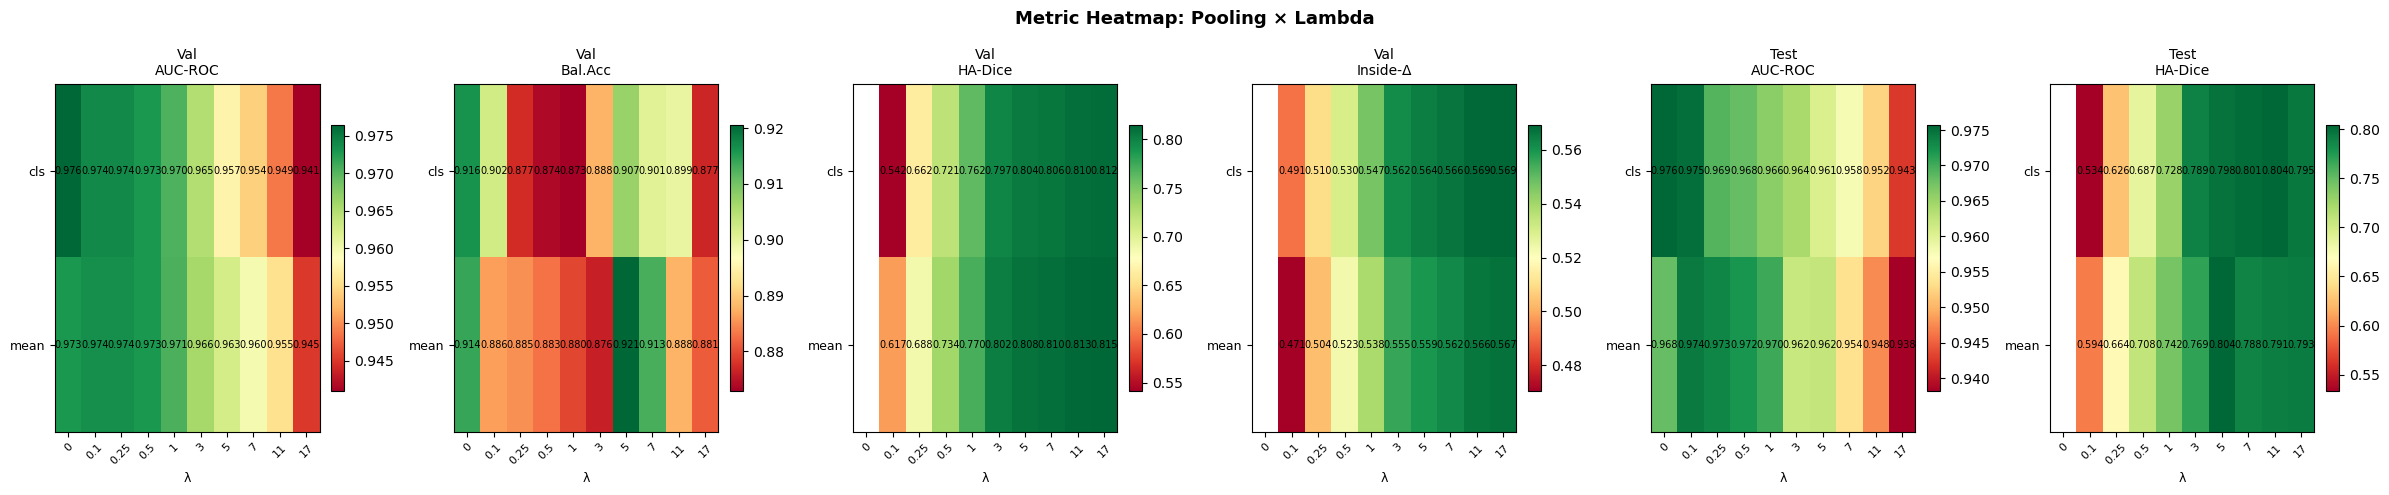

In [ ]:
# 
# 
# 
# 
# 
# 
# 
# 
# ----def plot_comprehensive_heatmap(df: pd.DataFrame) -> None:
    metrics_to_show = [
        ("val_auc_roc", "Val\nAUC-ROC"),
        ("val_balanced_acc", "Val\nBal.Acc"),
        ("val_ha_dice", "Val\nHA-Dice"),
        ("val_inside_minus", "Val\nInside-Δ"),
        ("test_auc_roc", "Test\nAUC-ROC"),
        ("test_ha_dice", "Test\nHA-Dice"),
    ]

    n_metrics = len(metrics_to_show)
    fig, axes = plt.subplots(1, n_metrics, figsize=(4 * n_metrics, 5))

    lambdas = sorted(df["ha_lambda"].dropna().unique())
    poolings = sorted(df["pooling"].dropna().unique())

    for ax, (col, label) in zip(axes, metrics_to_show):
        matrix = np.full((len(poolings), len(lambdas)), np.nan)

        for i, p in enumerate(poolings):
            for j, l in enumerate(lambdas):
                mask = (df["pooling"] == p) & (df["ha_lambda"] == l)
                values = df.loc[mask, col]

                if not values.empty and pd.notna(values.iloc[0]):
                    matrix[i, j] = values.iloc[0]

        if np.all(np.isnan(matrix)):
            ax.set_title(label, fontsize=10)
            ax.text(0.5, 0.5, "No data", ha="center", va="center")
            ax.axis("off")
            continue

        vmin = np.nanmin(matrix)
        vmax = np.nanmax(matrix)

        im = ax.imshow(
            matrix,
            aspect="auto",
            cmap="RdYlGn",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_xticks(range(len(lambdas)))
        ax.set_xticklabels([f"{l:.2g}" for l in lambdas], rotation=45, fontsize=8)
        ax.set_yticks(range(len(poolings)))
        ax.set_yticklabels(poolings, fontsize=9)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("λ", fontsize=9)

        for i in range(len(poolings)):
            for j in range(len(lambdas)):
                value = matrix[i, j]
                if not np.isnan(value):
                    ax.text(
                        j,
                        i,
                        f"{value:.3f}",
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="black",
                    )

        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle("Metric Heatmap: Pooling × Lambda", fontsize=13, fontweight="bold")
    plt.tight_layout()
    save_or_show(fig, "heatmap")


if not df.empty:
    plot_comprehensive_heatmap(df)

- What it shows: All metrics across all lambda values, colour coded green=good, red=bad.
- Reading: Val AUC and Test AUC are green on the left (low lambda) and turn red on the right (high lambda) — confirms classification degrades with lambda. Val HA-Dice and Val Inside-Δ are the opposite — green on the right. The Balanced Accuracy heatmap shows the interesting green island at λ=5 for mean pooling — the regularisation peak. Test AUC heatmap shows mean pooling stays greener than CLS at matched lambda across the board.

In [19]:
if not df.empty:
    candidate_cols = [
        "run_name",
        "pooling",
        "ha_lambda",
        "val_auc_roc",
        "val_balanced_acc",
        "val_ha_dice",
        "val_inside_minus",
        "test_auc_roc",
        "test_ha_dice",
        "test_inside_minus",
    ]

    candidates = df[candidate_cols].copy()

    candidates["auc_rank"] = candidates["val_auc_roc"].rank(ascending=False)
    candidates["align_rank"] = candidates["val_inside_minus"].rank(ascending=False)
    candidates["combined_rank"] = candidates["auc_rank"] + candidates["align_rank"]

    candidates = candidates.sort_values("combined_rank")

    display(candidates)

,run_name,pooling,ha_lambda,val_auc_roc,val_balanced_acc,val_ha_dice,val_inside_minus,test_auc_roc,test_ha_dice,test_inside_minus,auc_rank,align_rank,combined_rank
2,sweep_ha__cls__l0p25__ep10__lr1e5,cls,0.25,0.973838,0.877374,0.661654,0.509529,0.969100,0.626108,0.484504,3.0,15.0,18.0
1,sweep_ha__cls__l0p1__ep10__lr1e5,cls,0.10,0.973939,0.902323,0.541558,0.491013,0.975049,0.533659,0.480550,2.0,17.0,19.0
3,sweep_ha__cls__l0p5__ep10__lr1e5,cls,0.50,0.972727,0.874040,0.720894,0.530185,0.968169,0.686640,0.504507,7.0,13.0,20.0
5,sweep_ha__cls__l3p0__ep10__lr1e5,cls,3.00,0.964848,0.887879,0.796973,0.561609,0.964173,0.788556,0.545316,12.0,8.0,20.0
8,sweep_ha__cls__l11p0__ep10__lr1e5,cls,11.00,0.948889,0.899495,0.809846,0.568544,0.952351,0.804300,0.554980,18.0,2.0,20.0
12,sweep_ha__mean__l0p25__ep10__lr1e5,mean,0.25,0.973535,0.885152,0.687740,0.503691,0.973306,0.663723,0.485035,4.5,16.0,20.5
17,sweep_ha__mean__l7p0__ep10__lr1e5,mean,7.00,0.959596,0.912828,0.810416,0.562061,0.953598,0.788295,0.536234,14.0,7.0,21.0
15,sweep_ha__mean__l3p0__ep10__lr1e5,mean,3.00,0.965758,0.876263,0.802116,0.555465,0.962070,0.768724,0.523008,11.0,10.0,21.0
14,sweep_ha__mean__l1p0__ep10__lr1e5,mean,1.00,0.970606,0.879596,0.770218,0.538473,0.970182,0.742292,0.514706,9.0,12.0,21.0
13,sweep_ha__mean__l0p5__ep10__lr1e5,mean,0.50,0.972727,0.882929,0.734176,0.523282,0.972105,0.708241,0.503034,7.0,14.0,21.0


In [20]:
if not df.empty:
    max_auc = df["val_auc_roc"].max()
    allowed_auc_drop = 0.02

    pareto_candidates = df[
        df["val_auc_roc"] >= max_auc - allowed_auc_drop
    ].copy()

    pareto_candidates = pareto_candidates.sort_values(
        ["val_inside_minus", "val_ha_dice"],
        ascending=False,
    )

    print(f"Best val AUC: {max_auc:.4f}")
    print(f"Keeping models with val AUC >= {max_auc - allowed_auc_drop:.4f}")

    display(
        pareto_candidates[
            [
                "run_name",
                "pooling",
                "ha_lambda",
                "val_auc_roc",
                "val_balanced_acc",
                "val_ha_dice",
                "val_inside_minus",
                "test_auc_roc",
                "test_ha_dice",
                "test_inside_minus",
            ]
        ]
    )

Best val AUC: 0.9765
Keeping models with val AUC >= 0.9565


,run_name,pooling,ha_lambda,val_auc_roc,val_balanced_acc,val_ha_dice,val_inside_minus,test_auc_roc,test_ha_dice,test_inside_minus
6,sweep_ha__cls__l5p0__ep10__lr1e5,cls,5.00,0.957374,0.907273,0.803631,0.564363,0.960523,0.797935,0.550590
17,sweep_ha__mean__l7p0__ep10__lr1e5,mean,7.00,0.959596,0.912828,0.810416,0.562061,0.953598,0.788295,0.536234
5,sweep_ha__cls__l3p0__ep10__lr1e5,cls,3.00,0.964848,0.887879,0.796973,0.561609,0.964173,0.788556,0.545316
16,sweep_ha__mean__l5p0__ep10__lr1e5,mean,5.00,0.962525,0.920606,0.807684,0.559280,0.962325,0.803630,0.547843
15,sweep_ha__mean__l3p0__ep10__lr1e5,mean,3.00,0.965758,0.876263,0.802116,0.555465,0.962070,0.768724,0.523008
4,sweep_ha__cls__l1p0__ep10__lr1e5,cls,1.00,0.970404,0.872929,0.762197,0.546620,0.965946,0.728276,0.518638
14,sweep_ha__mean__l1p0__ep10__lr1e5,mean,1.00,0.970606,0.879596,0.770218,0.538473,0.970182,0.742292,0.514706
3,sweep_ha__cls__l0p5__ep10__lr1e5,cls,0.50,0.972727,0.874040,0.720894,0.530185,0.968169,0.686640,0.504507
13,sweep_ha__mean__l0p5__ep10__lr1e5,mean,0.50,0.972727,0.882929,0.734176,0.523282,0.972105,0.708241,0.503034
2,sweep_ha__cls__l0p25__ep10__lr1e5,cls,0.25,0.973838,0.877374,0.661654,0.509529,0.969100,0.626108,0.484504


Consensus: What the data tells you
1. λ=3 is the true operational boundary, not λ=5.
The alignment saturation plot proves it. After λ=3, marginal gains drop to ~0.003. Every model above λ=3 pays AUC cost for alignment gains that are statistically negligible.

2. Mean pooling is the better classifier under HA pressure.
At every lambda above 1, mean pooling holds higher val and test AUC. The gap is ~0.006 at λ=5 and grows to ~0.004 at λ=17. Mean also generalises better (Figure 4 AUC scatter).

3. CLS produces sharper CAMs.
The cam_nonzero_fraction curve (Figure 2 right) shows CLS activates ~30% of pixels at λ=3, while mean activates ~35%. Sharper CAM = more visually interpretable for a dermatologist. This is the only metric where CLS wins.

4. The balanced accuracy spike at mean/λ=5 is real but fragile.
It appears because HA regularisation at moderate lambda forces the model to attend to lesion-specific features, improving recall on the minority class. But it vanishes at λ=7 and above, suggesting it is sensitive to the exact lambda value rather than a robust effect.

5. High lambda (≥7) hurts generalisation without adding alignment.
Figure 4 shows test AUC falling below val AUC at high lambda for mean pooling. The model is memorising alignment patterns from the training masks rather than learning generalisable lesion attention.